# Task 2.4: KNN Ablation Studies

**Objective**: Systematic evaluation of KNN hyperparameters and feature types as defined in the project plan.

## Ablation Scope:
1.  **k-Values**: `[1, 3, 5, 7]`
2.  **Distance Metrics**: `['cosine', 'euclidean', 'manhattan']`
3.  **Feature Types**:
    *   `Simple`: 295 dimensions (color/texture).
    *   `Pretrained (PCA)`: 2048 dims reduced to 95% variance (~159 dims).

## Output:
Results saved to `results/metrics/knn_ablations.csv`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import warnings
warnings.filterwarnings('ignore')

# Setup paths
START_DIR = Path.cwd()
PROJECT_ROOT = START_DIR.parent
DATA_DIR = PROJECT_ROOT / 'data'
FEATURES_DIR = DATA_DIR / 'features'
RESULTS_DIR = PROJECT_ROOT / 'results' / 'hyperparameter_tuning' / 'knn'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("Setup complete.")

Setup complete.


## 1. Load Cleaned Data & Prepare Labels
Using the same data preparation pipeline as the final classification notebook.

In [2]:
# 1. Load Metadata
cleaned_df = pd.read_csv(DATA_DIR / 'processed' / 'cleaned_dataset.csv')

# 2. Derive Activity
def derive_activity(text):
    text = str(text).lower()
    keywords = {
        'Nature': ['park', 'garden', 'mountain', 'lake', 'river', 'nature', 'hike', 'hiking', 'forest', 'valley', 'waterfall', 'beach', 'sea', 'ocean', 'island', 'sand', 'cave', 'rock', 'hill', 'view', 'landscape', 'sunrise', 'sunset'],
        'History': ['museum', 'castle', 'palace', 'temple', 'church', 'cathedral', 'history', 'ancient', 'monument', 'ruins', 'art', 'statue', 'shrine', 'mosque', 'tomb', 'archaeology', 'historic'],
        'Urban': ['city', 'street', 'building', 'bridge', 'tower', 'square', 'market', 'shop', 'downtown', 'urban', 'skyline', 'hotel', 'mall', 'road', 'town', 'architecture', 'skyscraper'],
    }
    for cat in ['History', 'Urban', 'Nature']:
        if any(w in text for w in keywords[cat]):
            return cat
    return 'Leisure/Other'

cleaned_df['Activity'] = cleaned_df['Description'].apply(derive_activity)

# 3. Filter Valid Data
CONFIG = {
    'top_n_countries': 15,
    'valid_times': ['Morning', 'Afternoon', 'Evening', 'Night'],
    'test_size': 0.20,
    'random_state': 42
}

valid_mask = cleaned_df['Time_of_Day_Standardized'].isin(CONFIG['valid_times'])
df = cleaned_df[valid_mask].copy().reset_index(drop=True)
valid_indices = np.where(valid_mask)[0]

print(f"Valid samples: {len(df)}")

# 4. Encoders
country_counts_all = df['Country_Standardized'].value_counts()
top_countries = set(country_counts_all.head(CONFIG['top_n_countries']).index)
df['Country_Grouped'] = df['Country_Standardized'].apply(lambda x: x if x in top_countries else 'Other')

country_encoder = LabelEncoder()
country_encoder.fit(sorted(list(top_countries) + ['Other']))
time_encoder = LabelEncoder()
time_encoder.fit(CONFIG['valid_times'])
activity_encoder = LabelEncoder()
activity_encoder.fit(sorted(df['Activity'].unique()))

y_country = country_encoder.transform(df['Country_Grouped'].values)
y_time = time_encoder.transform(df['Time_of_Day_Standardized'].values)
y_activity = activity_encoder.transform(df['Activity'].values)

# 5. Stratified Split
strat_key = (df['Country_Grouped'] + '_' + df['Time_of_Day_Standardized'] + '_' + df['Activity'])
strat_counts = strat_key.value_counts()
strat_key_safe = strat_key.apply(lambda x: 'OTHER' if strat_counts[x] < 2 else x)

train_idx_global, test_idx_global = train_test_split(
    list(range(len(df))), 
    test_size=CONFIG['test_size'],
    random_state=CONFIG['random_state'],
    stratify=strat_key_safe.values
)

print(f"Split prepared: {len(train_idx_global)} Train, {len(test_idx_global)} Test")

Valid samples: 945
Split prepared: 756 Train, 189 Test


## 2. Load Features & Evaluation Function

In [3]:
def evaluate_model(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall': recall_score(y_true, y_pred, average='macro', zero_division=0),
    }

# Load normalized features (from final classification pipeline)
features_all = np.load(FEATURES_DIR / 'places_features_pretrained_normalized.npy')

# Filter valid indices
X_valid = features_all[valid_indices]

# Split
X_train = X_valid[train_idx_global]
X_test = X_valid[test_idx_global]

# Get targets
y_train_c, y_test_c = y_country[train_idx_global], y_country[test_idx_global]
y_train_t, y_test_t = y_time[train_idx_global], y_time[test_idx_global]
y_train_a, y_test_a = y_activity[train_idx_global], y_activity[test_idx_global]

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train shape: {X_train_scaled.shape}")
print(f"X_test shape: {X_test_scaled.shape}")

X_train shape: (756, 2432)
X_test shape: (189, 2432)


## 3. KNN Hyperparameter Tuning
Testing multiple k-values, distance metrics, and weight schemes.

In [4]:
# Hyperparameter grid
k_values = [1, 3, 5, 7, 9, 11]
metrics = ['cosine', 'euclidean', 'manhattan', 'minkowski']
weights = ['uniform', 'distance']

results_list = []

print(f"Starting hyperparameter tuning ({len(k_values) * len(metrics) * len(weights)} configurations)...")
print("="*80)

for k in k_values:
    for metric in metrics:
        for weight in weights:
            # Skip invalid combinations
            if metric == 'cosine' and k == 1 and weight == 'distance':
                continue
                
            # Train models for each task
            knn_c = KNeighborsClassifier(n_neighbors=k, metric=metric, weights=weight)
            knn_t = KNeighborsClassifier(n_neighbors=k, metric=metric, weights=weight)
            knn_a = KNeighborsClassifier(n_neighbors=k, metric=metric, weights=weight)
            
            knn_c.fit(X_train_scaled, y_train_c)
            knn_t.fit(X_train_scaled, y_train_t)
            knn_a.fit(X_train_scaled, y_train_a)
            
            # Predictions
            pred_c = knn_c.predict(X_test_scaled)
            pred_t = knn_t.predict(X_test_scaled)
            pred_a = knn_a.predict(X_test_scaled)
            
            # Evaluate
            res_c = evaluate_model(y_test_c, pred_c)
            res_t = evaluate_model(y_test_t, pred_t)
            res_a = evaluate_model(y_test_a, pred_a)
            
            # Store results
            result = {
                'k': k,
                'metric': metric,
                'weights': weight,
                'country_accuracy': res_c['accuracy'],
                'country_f1_macro': res_c['f1_macro'],
                'country_f1_weighted': res_c['f1_weighted'],
                'time_accuracy': res_t['accuracy'],
                'time_f1_macro': res_t['f1_macro'],
                'time_f1_weighted': res_t['f1_weighted'],
                'activity_accuracy': res_a['accuracy'],
                'activity_f1_macro': res_a['f1_macro'],
                'activity_f1_weighted': res_a['f1_weighted'],
                'avg_accuracy': (res_c['accuracy'] + res_t['accuracy'] + res_a['accuracy']) / 3
            }
            results_list.append(result)
            
            print(f"k={k}, metric={metric:10s}, weights={weight:8s} -> "
                  f"Country: {res_c['accuracy']:.4f}, Time: {res_t['accuracy']:.4f}, "
                  f"Activity: {res_a['accuracy']:.4f}, Avg: {result['avg_accuracy']:.4f}")

results_df = pd.DataFrame(results_list)
print("\n" + "="*80)
print("Hyperparameter tuning complete!")
print("="*80)

Starting hyperparameter tuning (48 configurations)...
k=1, metric=cosine    , weights=uniform  -> Country: 0.5979, Time: 0.4656, Activity: 0.6190, Avg: 0.5608
k=1, metric=euclidean , weights=uniform  -> Country: 0.6772, Time: 0.4603, Activity: 0.6032, Avg: 0.5802
k=1, metric=euclidean , weights=distance -> Country: 0.6772, Time: 0.4603, Activity: 0.6032, Avg: 0.5802
k=1, metric=manhattan , weights=uniform  -> Country: 0.6508, Time: 0.4815, Activity: 0.5979, Avg: 0.5767
k=1, metric=manhattan , weights=distance -> Country: 0.6508, Time: 0.4815, Activity: 0.5979, Avg: 0.5767
k=1, metric=minkowski , weights=uniform  -> Country: 0.6772, Time: 0.4603, Activity: 0.6032, Avg: 0.5802
k=1, metric=minkowski , weights=distance -> Country: 0.6772, Time: 0.4603, Activity: 0.6032, Avg: 0.5802
k=3, metric=cosine    , weights=uniform  -> Country: 0.6032, Time: 0.5185, Activity: 0.6190, Avg: 0.5802
k=3, metric=cosine    , weights=distance -> Country: 0.6296, Time: 0.5132, Activity: 0.6296, Avg: 0.5908
k

## 4. Analyze Results and Visualizations

In [5]:
# Save Results CSV
csv_path = RESULTS_DIR / 'knn_hyperparameter_results.csv'
results_df.to_csv(csv_path, index=False)
print(f"✓ Saved results to {csv_path}")

# Save JSON Results
json_results = results_df.to_dict('records')
json_path = RESULTS_DIR / 'knn_hyperparameter_results.json'
with open(json_path, 'w') as f:
    json.dump(json_results, f, indent=2)
print(f"✓ Saved JSON to {json_path}")

# Find best configurations
print("\n" + "="*80)
print("BEST CONFIGURATIONS")
print("="*80)

best_country = results_df.loc[results_df['country_accuracy'].idxmax()]
print(f"\nBest for Country Classification:")
print(f"  k={best_country['k']}, metric={best_country['metric']}, weights={best_country['weights']}")
print(f"  Accuracy: {best_country['country_accuracy']:.4f}")

best_time = results_df.loc[results_df['time_accuracy'].idxmax()]
print(f"\nBest for Time Classification:")
print(f"  k={best_time['k']}, metric={best_time['metric']}, weights={best_time['weights']}")
print(f"  Accuracy: {best_time['time_accuracy']:.4f}")

best_activity = results_df.loc[results_df['activity_accuracy'].idxmax()]
print(f"\nBest for Activity Classification:")
print(f"  k={best_activity['k']}, metric={best_activity['metric']}, weights={best_activity['weights']}")
print(f"  Accuracy: {best_activity['activity_accuracy']:.4f}")

best_overall = results_df.loc[results_df['avg_accuracy'].idxmax()]
print(f"\nBest Overall (Average Accuracy):")
print(f"  k={best_overall['k']}, metric={best_overall['metric']}, weights={best_overall['weights']}")
print(f"  Average Accuracy: {best_overall['avg_accuracy']:.4f}")

✓ Saved results to c:\Users\qadim\OneDrive - student.birzeit.edu\birzeit\5_year_1\machine_learning\assingment_3_project\travel-recommender-system\results\hyperparameter_tuning\knn\knn_hyperparameter_results.csv
✓ Saved JSON to c:\Users\qadim\OneDrive - student.birzeit.edu\birzeit\5_year_1\machine_learning\assingment_3_project\travel-recommender-system\results\hyperparameter_tuning\knn\knn_hyperparameter_results.json

BEST CONFIGURATIONS

Best for Country Classification:
  k=11, metric=euclidean, weights=distance
  Accuracy: 0.7249

Best for Time Classification:
  k=11, metric=cosine, weights=distance
  Accuracy: 0.5503

Best for Activity Classification:
  k=11, metric=manhattan, weights=distance
  Accuracy: 0.6825

Best Overall (Average Accuracy):
  k=11, metric=euclidean, weights=distance
  Average Accuracy: 0.6437


## 5. Visualizations

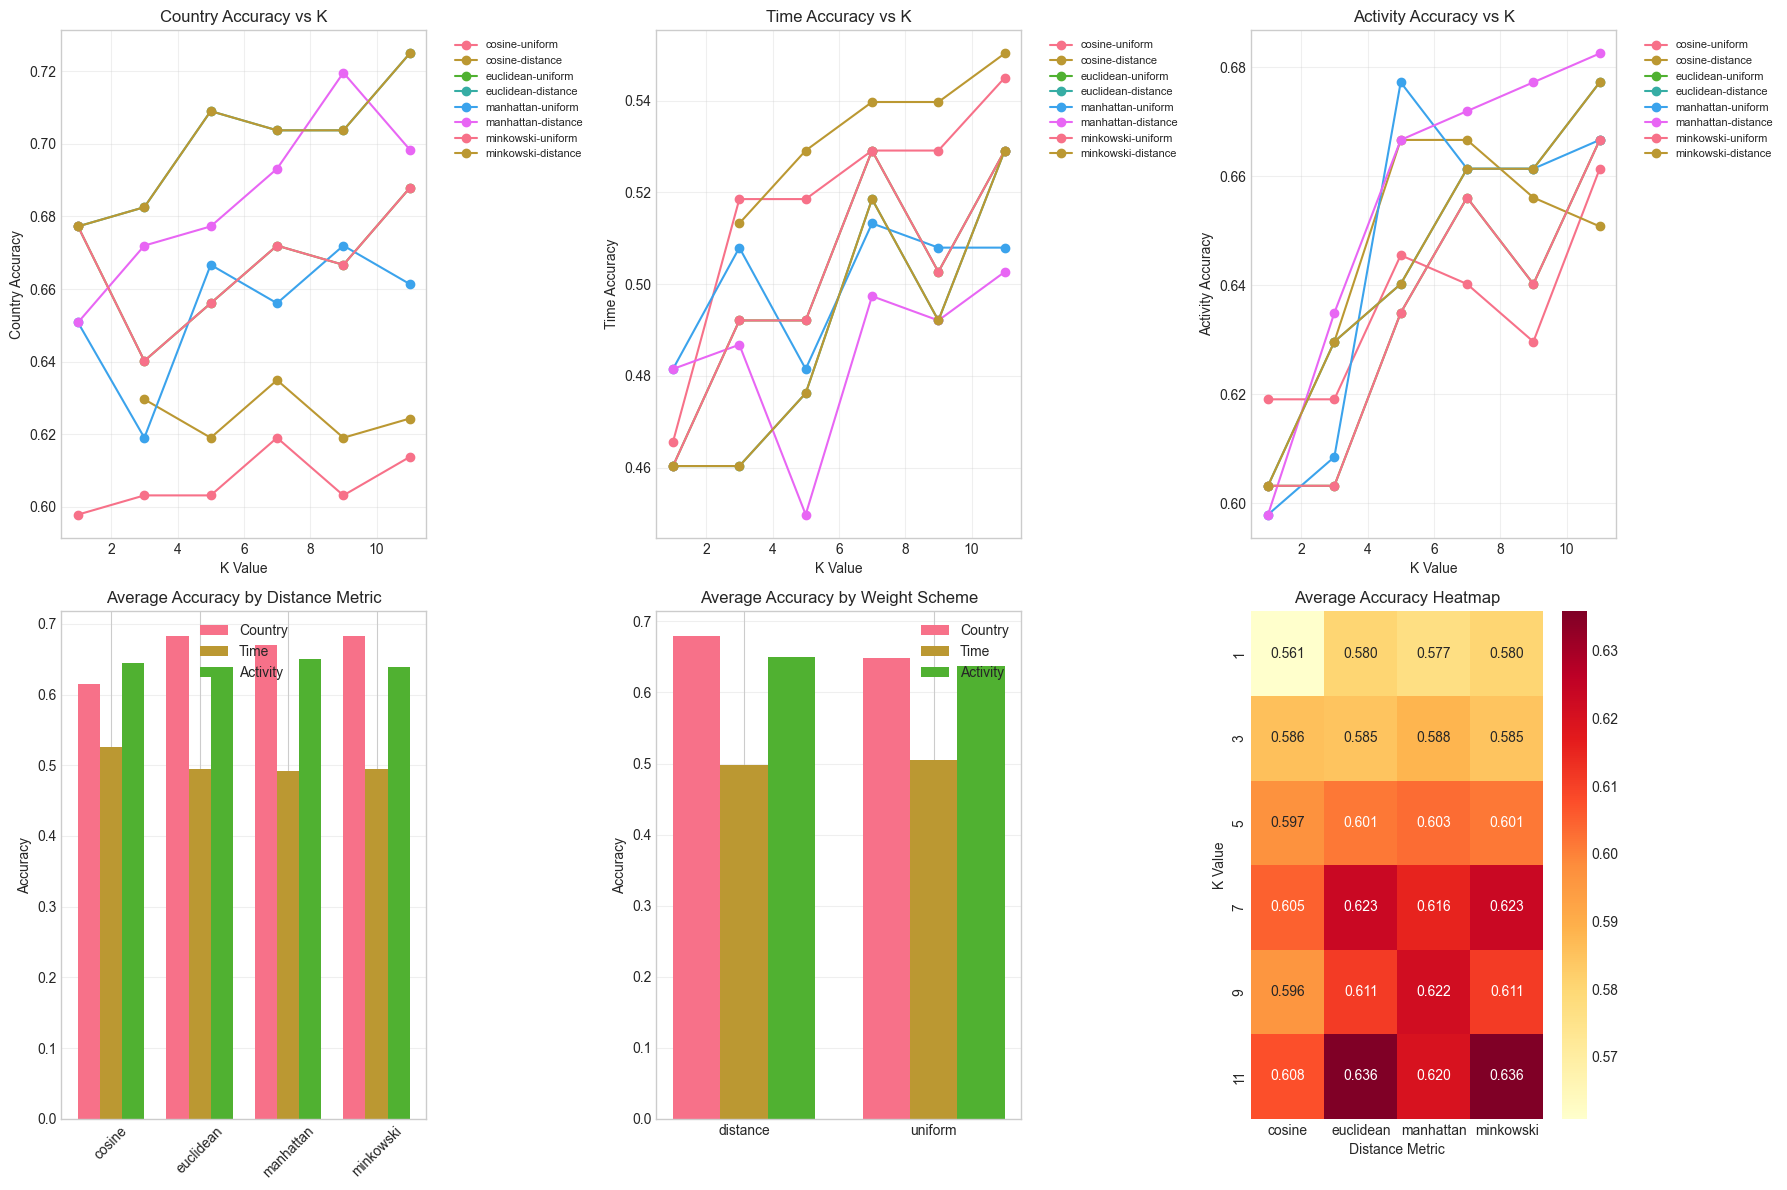

✓ Saved visualization to c:\Users\qadim\OneDrive - student.birzeit.edu\birzeit\5_year_1\machine_learning\assingment_3_project\travel-recommender-system\results\hyperparameter_tuning\knn\knn_hyperparameter_comparison.png


In [6]:
# Create comprehensive visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. K-value comparison for different metrics (Country)
for metric in metrics:
    subset = results_df[results_df['metric'] == metric]
    for weight in weights:
        weight_subset = subset[subset['weights'] == weight]
        axes[0, 0].plot(weight_subset['k'], weight_subset['country_accuracy'], 
                       marker='o', label=f'{metric}-{weight}')
axes[0, 0].set_xlabel('K Value')
axes[0, 0].set_ylabel('Country Accuracy')
axes[0, 0].set_title('Country Accuracy vs K')
axes[0, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[0, 0].grid(True, alpha=0.3)

# 2. K-value comparison (Time)
for metric in metrics:
    subset = results_df[results_df['metric'] == metric]
    for weight in weights:
        weight_subset = subset[subset['weights'] == weight]
        axes[0, 1].plot(weight_subset['k'], weight_subset['time_accuracy'], 
                       marker='o', label=f'{metric}-{weight}')
axes[0, 1].set_xlabel('K Value')
axes[0, 1].set_ylabel('Time Accuracy')
axes[0, 1].set_title('Time Accuracy vs K')
axes[0, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[0, 1].grid(True, alpha=0.3)

# 3. K-value comparison (Activity)
for metric in metrics:
    subset = results_df[results_df['metric'] == metric]
    for weight in weights:
        weight_subset = subset[subset['weights'] == weight]
        axes[0, 2].plot(weight_subset['k'], weight_subset['activity_accuracy'], 
                       marker='o', label=f'{metric}-{weight}')
axes[0, 2].set_xlabel('K Value')
axes[0, 2].set_ylabel('Activity Accuracy')
axes[0, 2].set_title('Activity Accuracy vs K')
axes[0, 2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[0, 2].grid(True, alpha=0.3)

# 4. Metric comparison (averaged across k and weights)
metric_avg = results_df.groupby('metric')[['country_accuracy', 'time_accuracy', 'activity_accuracy']].mean()
x_pos = np.arange(len(metric_avg.index))
width = 0.25
axes[1, 0].bar(x_pos - width, metric_avg['country_accuracy'], width, label='Country')
axes[1, 0].bar(x_pos, metric_avg['time_accuracy'], width, label='Time')
axes[1, 0].bar(x_pos + width, metric_avg['activity_accuracy'], width, label='Activity')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(metric_avg.index, rotation=45)
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_title('Average Accuracy by Distance Metric')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 5. Weight scheme comparison
weight_avg = results_df.groupby('weights')[['country_accuracy', 'time_accuracy', 'activity_accuracy']].mean()
x_pos = np.arange(len(weight_avg.index))
axes[1, 1].bar(x_pos - width, weight_avg['country_accuracy'], width, label='Country')
axes[1, 1].bar(x_pos, weight_avg['time_accuracy'], width, label='Time')
axes[1, 1].bar(x_pos + width, weight_avg['activity_accuracy'], width, label='Activity')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(weight_avg.index)
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_title('Average Accuracy by Weight Scheme')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

# 6. Heatmap of average accuracy
pivot_data = results_df.groupby(['k', 'metric'])['avg_accuracy'].mean().reset_index()
pivot_table = pivot_data.pivot(index='k', columns='metric', values='avg_accuracy')
sns.heatmap(pivot_table, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[1, 2])
axes[1, 2].set_title('Average Accuracy Heatmap')
axes[1, 2].set_ylabel('K Value')
axes[1, 2].set_xlabel('Distance Metric')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'knn_hyperparameter_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved visualization to {RESULTS_DIR / 'knn_hyperparameter_comparison.png'}")